# Recall Analysis Statistics

This Notebook is analysing the Data properly from our experiments: After Loading the Data and Computing all the features, here, we are making 

### Load Data

#### Parameters

In [21]:
### Imports
import matplotlib.pyplot as plt

ANNAME = "TEST_withoutCenter_resVAR100_dgv5_bll500_blb75_smw10_smL2000_swG50_trO10000_trB0mean" ### WORK
EXPNAME = "SecondExp"
### Parameters and Globals
DATAFOLDER = "data_second"       # Data Folder for experiment
LABELING = False                 # Labeling Mode
CLASSESS =  {1:"Focus",          # Classess Dictionairy t understand what means what
             2:"Task-Related Thoughts", 
             3: "Mind Wandering",
             4: "Mind Wandering"}

CONTINUE = True
VERBOSE = False


### Create Data Name First
CLASSN = 4                       # Number of MW Discrete Classess
SUBJECTS = ['ELMA2108','JUBE2907']   
SHORTLEMMAS = True   # Whether to include Utterances that have simple to little Lemmas
VIZFOLDER = f"FULLextrF_{CLASSN}_{SHORTLEMMAS}_all"

### Adjust to current Setting 
SHORTLEMMAS = False   # Whether to include Utterances that have simple to little Lemmas
CLASSN = 2                      # Number of MW Discrete Classess

if type(SUBJECTS) == list: # If there are Subject to filterOut
    SNAME = "sFiltered"
else:
    SNAME = "sAll"

if SHORTLEMMAS:
    SHORTL = "Short"
else:
    SHORTL = "NoShort"

    
ANALYSIS_NAME = f"FULLextrF_{CLASSN}_{SHORTL}_{SNAME}" # For the time when you want a different save folder


#### Load and Preprocess DFs

here we load:
- dfData - Utterances, Fragments and Lemmas
- dfAnalysis - preprocessed Sematnic Features
- dfEyeData - Occular + Behavioral Features

We also slightly preprocess our: data:
- Change column names in dfAnalysis
- normalsie MW_Estimates
- remove any unnecessery and faulty columns
- renaming Subjects and Fragments in dfAnalysis and dfData to match the dfEyeData


Finally, We Merge dfAnal;ysis with dfEyeData on trialNum and DS. checking if the joining is correct 

In [22]:
####    Load Necessery Variables and Paths:
import os 
from storyTools import loadStory,splitStoryEntity,reLabel
import pandas as pd
import numpy as np 
import pickle
from matplotlib.backends.backend_pdf import PdfPages

### General Working, Data, and Saving Path:
workingDir = os.getcwd();                                 # Current Folder
path = os.path.split(workingDir)[0] + "\\" + DATAFOLDER   # Data path
savePathRecall = os.path.join(workingDir,EXPNAME,'Recalls')       # Save Path for Recall results
loadPathFeatures = os.path.join(workingDir,EXPNAME,'RecallAnalysis',VIZFOLDER)
savePathFeatures = os.path.join(workingDir,EXPNAME,'RecallAnalysis',ANALYSIS_NAME)

if os.path.isdir(savePathFeatures) == 0:
    os.makedirs(savePathFeatures) # Create a directory for recall results

subjects = [f for f in os.listdir(path) if  not os.path.isfile(os.path.join(path, f))]  # get all the filenames


### Get Polish Stopwords:
with open(r"C:\Users\barak\Documents\Python_Scripts\CoproraTools\polish.stopwords.txt", encoding="utf-8") as f:
    polish_stopwords = set(line.strip().lower() for line in f if line.strip())





### Load Previous Excel File with Data:
dfData = pd.read_excel(os.path.join(loadPathFeatures,"data.xlsx"), index_col=0)
dfAnalysis = pd.read_excel(os.path.join(loadPathFeatures,"features.xlsx"), index_col=0)
### Load Eye and BEhavioral Data:
dfEyeData = pd.read_excel(os.path.join(os.path.join(workingDir,EXPNAME,ANNAME,'summary'),"all_data.xlsx"),header=[0, 1, 2])

# Replace 'Unnamed' with empty string in all levels
dfEyeData.columns = pd.MultiIndex.from_tuples(
    tuple('' if "Unnamed" in str(x) else x for x in col)
    for col in dfEyeData.columns
)
dfEyeData.drop(0,axis=0,inplace=True)


### Normalise the MW Count:
for sn,s in enumerate(dfEyeData['DS'].unique()):
    m = float(dfEyeData[['MW_Estimate','DS']].groupby('DS').mean().iloc[sn])
    st = float(dfEyeData[['MW_Estimate','DS']].groupby('DS').std().iloc[sn])

    dfEyeData.loc[dfEyeData[('DS', '', '')] == s, ('MW_Estimate', '', '')] = (dfEyeData.loc[dfEyeData['DS'] == s, 'MW_Estimate'] - m) / st


C:\Users\barak\AppData\Local\Temp\ipykernel_35368\279756712.py:46: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  m = float(dfEyeData[['MW_Estimate','DS']].groupby('DS').mean().iloc[sn])
C:\Users\barak\AppData\Local\Temp\ipykernel_35368\279756712.py:47: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  st = float(dfEyeData[['MW_Estimate','DS']].groupby('DS').std().iloc[sn])
C:\Users\barak\AppData\Local\Temp\ipykernel_35368\279756712.py:46: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  m = float(dfEyeData[['MW_Estimate','DS']].groupby('DS').mean().iloc[sn])
C:\Users\barak\AppData\Local\Temp\ipykernel_35368\279756712.py:47: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  st = float(dfEyeData[['MW_Estimate','DS']].groupby('DS').std().il

In [23]:
### Change the column names for something more palatable

dfAnalysis.rename(columns={'utt_leng' : 'Utterance Length',
                           'LexDivS'  : 'Subject LexDiv',
                           'LexDivSS' : 'All Data LexDiv',
                           'LemEmbBert' : 'Lemma Embeddings BERT',
                           'LemEmbFtxt' : 'Lemma Embeddings FastText',
                           'NounEmb' : 'Noun Embeddings BERT',
                           'VerbEmb' : 'Verb Embeddings BERT',
                           'wmd' : 'Word Mover Distance Subject',
                           'wmdS' : 'Word Mover Distance Dataset',
                           'Focus' : 'BERTopic Focus Prob',
                           'Task-Related Thoughts' : 'BERTopic TRT Prob',
                           'Mind Wandering' : 'BERTopic MW Prob',
                           'Mind Blanking' : 'BERTopic MB Prob',
                           'FragmentSentCosSim': 'Frag-Utt Cosine Sim (Sentance)',
                           'FragmentLemmaCosSim': 'Frag-Utt Cosine Sim (Lemma)',
                           'wmdFragments': 'Frag-Utt Word Mover Distance',
                           'perpBert': 'Bert Perplexity',
                           'perpBertC': 'Bert Perplexity (Fragment Context)',
                           'perpGLM': 'GLM Perplexity ',
                           'perpGLMC': 'GLM Perplexity (Fragment Context)',
                           'LemmaWeights': 'Semantic Web Weights of Utterance',
                           },inplace = True)




In [24]:
len(dfAnalysis['Subject'].unique())

dfAnalysis['Subject'].unique()

array(['ADNA2507', 'AGBA0708', 'ANLU2607', 'JUBE2907', 'JUWO0708',
       'MANI2607', 'NIZA2907', 'PIKR2907', 'ANBA2308', 'BAZA2108',
       'BEWA2308', 'ELMA2108', 'EWSI2308', 'JAJA2108', 'KABE2308',
       'KAFI2108', 'WIJA2308', 'IZPR2608', 'KLKR2608', 'MAMA2608',
       'PASZ2608', 'ANGU1309', 'ANSW1409', 'EDJA1309', 'IGWI1409',
       'MOWA1009', 'OSJA1309', 'SAMA1409', 'TYTO1309'], dtype=object)

In [25]:
dfAnalysis

,Subject,Fragment,Attention,Utterance Length,Tracked,lemmaN,NounsN,VerbsN,LexDiv,Subject LexDiv,...,Frag-Utt Cosine Sim (Sentance),Frag-Utt Cosine Sim (Lemma),Frag-Utt Word Mover Distance,Bert Perplexity,Bert Perplexity (Fragment Context),GLM Perplexity,GLM Perplexity (Fragment Context),Semantic Web Weights of Utterance,LemEmbS,LemEmbC
0,ADNA2507,recall_JANEK_1,1,121,TRACKED,12,5,3,1.000000,0.035821,...,0.705140,0.978090,0.993028,183.375958,109.630474,2096.313051,707.567748,5.054545,NaN,NaN
1,ADNA2507,recall_JANEK_10,1,146,TRACKED,14,6,3,1.000000,0.041791,...,0.494516,0.970626,0.996682,2761.725960,1541.140149,5109.196236,2447.765464,4.807692,NaN,NaN
2,ADNA2507,recall_JANEK_11,1,121,TRACKED,11,3,4,1.000000,0.032836,...,0.524925,0.960047,1.052688,48.298661,37.887278,3618.984519,1055.336137,4.170000,NaN,NaN
3,ADNA2507,recall_JANEK_12,1,170,TRACKED,16,11,4,0.937500,0.044776,...,0.432184,0.970627,1.062327,185.007199,89.721509,1364.457967,620.646585,3.930769,NaN,NaN
4,ADNA2507,recall_JANEK_13,1,164,TRACKED,12,7,2,0.916667,0.032836,...,0.509663,0.968182,0.985492,66.730218,77.376585,2407.235756,1270.224346,3.309091,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,TYTO1309,recall_KAROLINA_5,2,215,TRACKED,18,7,6,0.833333,0.048701,...,0.313535,0.639037,1.060897,50.532619,37.748751,1680.963791,1149.061676,6.300000,0.658629,0.641488
316,TYTO1309,recall_KAROLINA_6,3,279,TRACKED,19,4,10,0.947368,0.058442,...,0.356618,0.632873,1.100957,9.011170,9.281936,1161.935298,958.610837,5.750000,0.668746,0.651858
317,TYTO1309,recall_KAROLINA_7,1,208,TRACKED,13,6,7,0.923077,0.038961,...,0.235926,0.595104,0.980783,15.776520,11.757468,1418.243612,786.448467,7.566667,0.636920,0.621269
318,TYTO1309,recall_KAROLINA_8,4,307,TRACKED,23,7,8,0.826087,0.061688,...,0.256268,0.624597,1.107749,89.337760,109.200082,1804.093812,1277.765682,7.773684,0.679388,0.661908


In [26]:
### RenameSubjects: and Rename the trialNumbers
subjPaths = [ f.name for f in os.scandir(savePathRecall) if f.is_dir() ]
import re
from itertools import zip_longest
dfData['DS'] = dfData['Subject']
dfAnalysis['DS'] = dfData['Subject']

fragmentEquivalenceDF = pd.read_excel( os.path.join(workingDir,EXPNAME,'RecallAnalysis',VIZFOLDER,"fragEquiv.xlsx"), index_col=0)
for sn,s in enumerate(subjPaths):
    currSlice = dfData['Subject'] == s

    dfData['DS'][currSlice] = f'DS{int(sn+1):02d}'
    dfAnalysis['DS'][currSlice] = f'DS{int(sn+1):02d}'


dfData = dfData.merge(fragmentEquivalenceDF,on="Fragment")         # Join with DF giving the Trial Numbers
dfAnalysis = dfAnalysis.merge(fragmentEquivalenceDF,on="Fragment")
dfAnalysis.drop(['LemEmbS','LemEmbC'],axis=1,inplace=True )

if CLASSN ==2: # Collapse Clasesess
    dfAnalysis.loc[dfAnalysis['Attention'] == 2,'Attention']= 1
    dfAnalysis.loc[dfAnalysis['Attention'] == 4,'Attention'] = 3


In [ ]:
### Merge Eye Data and Utterance Data

def pad_columns(df, depth, fill=''):
    """
        Quick Function to pad one-level column DF to a preset depth adding levels
    """
    if not isinstance(df.columns, pd.MultiIndex):
        df.columns = pd.MultiIndex.from_tuples([(c,) + (fill,) * (depth - 1) for c in df.columns])
    elif df.columns.nlevels < depth:
        df.columns = pd.MultiIndex.from_tuples(
            [tuple(col) + (fill,) * (depth - len(col)) for col in df.columns]
            for col in df.columns
        )
    return df

# Pad dfAnalysis columns to 3 levels
dfAnalysis = pad_columns(dfAnalysis, 3)
dfAnalysis[('trialNum', '', '')] +=1
# Now merge using the correct tuple for 'trialNum'
merged = dfEyeData.merge(dfAnalysis, on=[('DS', '', ''),('trialNum', '', '')])
merged


MW_Estimate GazeDifference Pupil_Diameter               \
                                                  Mean                
                                              Left_Eye    Right_Eye   
0        0.0    1.151388      82.308603    4381.319465  4279.315800   
1        0.0    1.151388      82.308603    4381.319465  4279.315800   
2        0.0    1.151388      82.308603    4381.319465  4279.315800   
3        0.0    1.151388      82.308603    4381.319465  4279.315800   
4        1.0   -0.769815      36.474116    4915.607693  4434.471185   
...      ...         ...            ...            ...          ...   
1091  1037.0    4.062853      30.417250    4140.107510  4037.408077   
1092  1037.0    4.062853      30.417250    4140.107510  4037.408077   
1093  1037.0    4.062853      30.417250    4140.107510  4037.408077   
1094  1038.0    2.998059      21.600760    4227.974282  4100.413388   
1095  1038.0    2.998059      21.600760    4227.974282  4100.413388   

                                                                   ...  \
               Std                    diff                    auc  ...   
          Left_Eye     Right_Eye  Left_Eye Right_Eye     Left_Eye  ...   
0     63266.073017  33602.645894  0.555289  0.487667  4376.924499  ...   
1     63266.073017  33602.645894  0.555289  0.487667  4376.924499  ...   
2     63266.073017  33602.645894  0.555289  0.487667  4376.924499  ...   
3     63266.073017  33602.645894  0.555289  0.487667  4376.924499  ...   
4     21324.827150  11888.845256 -0.226533 -0.248433  4910.833534  ...   
...            ...           ...       ...       ...          ...  ...   
1091  35047.211177  23644.689273 -0.459700 -0.377700  4135.925842  ...   
1092  35047.211177  23644.689273 -0.459700 -0.377700  4135.925842  ...   
1093  35047.211177  23644.689273 -0.459700 -0.377700  4135.925842  ...   
1094  37835.321921  27416.081740 -0.480556 -0.562500  4223.291313  ...   
1095  37835.321921  27416.081740 -0.480556 -0.562500  4223.291313  ...   

     BERTopic MW Prob BERTopic MB Prob Frag-Utt Cosine Sim (Sentance)  \
                                                                        
                                                                        
0            0.041048         0.003280                       0.705140   
1            0.163423         0.401302                       0.238161   
2            0.403603         0.061356                       0.201933   
3            0.037921         0.022928                       0.197639   
4            0.084894         0.005909                       0.466486   
...               ...              ...                            ...   
1091         0.019449         0.004633                       0.213118   
1092         0.235722         0.003953                       0.298739   
1093         0.123436         0.023944                       0.361540   
1094         0.681067         0.192636                       0.250241   
1095         0.410138         0.007382                       0.169078   

     Frag-Utt Cosine Sim (Lemma) Frag-Utt Word Mover Distance Bert Perplexity  \
                                                                                
                                                                                
0                       0.978090                     0.993028      183.375958   
1                       0.606440                     1.082113      114.957813   
2                       0.595167                     1.081804       21.707363   
3                       0.593843                     1.145427       83.134065   
4                       0.966863                     1.042697      307.434135   
...                          ...                          ...             ...   
1091                    0.956363                     1.173779      208.208851   
1092                    0.577279                     1.036595       23.880851   
1093                    0.611934                     1.011705      

### Add Checks and Select Quality Data: 


In [28]:
#### QUALITY CHECKS FOR THE DATA NUMBER 
### CHECK - whether all has been merged Correctly 
keys = ["Subject", "trialNum"]

# de-dup keys (important if merged is m:1)
ana_keys = dfAnalysis[keys].drop_duplicates()
mer_keys = merged[keys].drop_duplicates()

# 1) In dfAnalysis but NOT in merged
missing_keys = (
    pd.MultiIndex.from_frame(ana_keys)
    .difference(pd.MultiIndex.from_frame(mer_keys))
)
missing_from_merged = (
    dfAnalysis.set_index(keys).loc[missing_keys].reset_index()
)

print(f"Number of absent EyeData Rows:    {len(dfEyeData) - len(dfAnalysis)}")
print(f"Number of Missed dfAnalysis Rows: {len(missing_from_merged)}")

print("===== Subject Wise Checks =====")
checks = merged[[('Subject','',''),
            ('Pupil_Diameter','Mean','Left_Eye'),
            ('Checks','', 'saccadeRate'),
            ('Checks','', 'blinkRate'),
            ('Checks','', 'goodRatioLeft'),
            ('Checks','', 'gazeRate'),
            ('Checks','', 'gazeDiff'),
            ('Blinks','', 'BlinkDuration'),
            ('Utterance Length','',''),
            ('lemmaN','','')]]
checks.columns = checks.columns.to_series().apply(''.join)
checks[['ChecksblinkRate']] = checks[['ChecksblinkRate']].apply(lambda x: x*1000*1000)
checks[['CheckssaccadeRate']] = checks[['CheckssaccadeRate']].apply(lambda x: x*1000*1000)

checks.groupby('Subject').agg('mean','std')

Number of absent EyeData Rows:    75
Number of Missed dfAnalysis Rows: 29
===== Subject Wise Checks =====


,Pupil_DiameterMeanLeft_Eye,CheckssaccadeRate,ChecksblinkRate,ChecksgoodRatioLeft,ChecksgazeRate,ChecksgazeDiff,BlinksBlinkDuration,Utterance Length,lemmaN
Subject,,,,,,,,,
ADNA2507,5051.399282,3.585250e+06,1.763526e+06,0.966551,0.130449,62.396119,141.359419,162.923077,14.000000
AGBA0708,6379.721514,3.130751e+06,1.239370e+06,0.979578,0.084450,36.126155,100.927228,146.128205,11.230769
ANBA2308,5051.399282,3.585250e+06,1.763526e+06,0.966551,0.130449,62.396119,141.359419,278.358974,20.076923
ANGU1309,5051.399282,3.585250e+06,1.763526e+06,0.966551,0.130449,62.396119,141.359419,398.615385,26.641026
ANLU2607,5869.513762,2.596144e+06,1.673954e+06,0.964335,0.204315,44.566266,196.524013,172.256410,14.256410
ANSW1409,6379.721514,3.130751e+06,1.239370e+06,0.979578,0.084450,36.126155,100.927228,194.384615,14.820513
BAZA2108,6398.620556,3.105313e+06,1.241639e+06,0.980215,0.084044,35.926624,100.240816,143.200000,10.314286
BEWA2308,5902.306449,2.614932e+06,1.606477e+06,0.964801,0.191586,43.342364,189.549654,202.794872,14.846154
EDJA1309,5869.513762,2.596144e+06,1.673954e+06,0.964335,0.204315,44.566266,196.524013,134.666667,11.923077


In [29]:
if type(SUBJECTS) == list: # If there are Subject to filterOut
    # Get all of the Rows that do not contain this subjec
    merged = merged[merged['Subject'].apply(lambda x: True if x not in SUBJECTS else False)]
if not SHORTLEMMAS:
    merged = merged[merged['lemmaN'] > 5]

In [30]:
missing_from_merged

,Subject,trialNum,Fragment,Attention,Utterance Length,Tracked,lemmaN,NounsN,VerbsN,LexDiv,...,BERTopic MB Prob,Frag-Utt Cosine Sim (Sentance),Frag-Utt Cosine Sim (Lemma),Frag-Utt Word Mover Distance,Bert Perplexity,Bert Perplexity (Fragment Context),GLM Perplexity,GLM Perplexity (Fragment Context),Semantic Web Weights of Utterance,DS
,,,,,,,,,,,...,,,,,,,,,,
,,,,,,,,,,,...,,,,,,,,,,
0,ADNA2507,0,recall_KAROLINA_1,3,118,UNTRACKED,10,6,3,0.900000,...,0.028776,0.444574,0.963214,1.155955,78.490749,74.447647,5793.537372,1493.489777,5.078571,DS01
1,AGBA0708,0,recall_KAROLINA_1,1,191,TRACKED,13,4,7,0.846154,...,0.124624,0.323019,0.937759,1.161684,14.499398,14.306504,1493.898607,995.271074,4.625000,DS02
2,ANBA2308,0,recall_KAROLINA_1,1,195,TRACKED,17,8,7,0.941176,...,0.076863,0.219194,0.574937,1.126384,16.596810,15.236353,2743.027908,1730.303842,4.714286,DS01
3,ANGU1309,0,recall_KAROLINA_1,1,209,TRACKED,15,6,4,1.000000,...,0.051295,0.200911,0.565519,1.154412,145.120452,128.068350,2814.821513,2124.620215,5.933333,DS01
4,ANLU2607,0,recall_KAROLINA_1,1,293,UNTRACKED,23,8,10,0.782609,...,0.039028,0.505741,0.974176,1.051526,28.417778,29.115441,964.993470,815.423958,5.265909,DS05
5,ANSW1409,0,recall_KAROLINA_1,1,200,UNTRACKED,16,8,5,0.812500,...,0.033493,0.270025,0.541921,1.101047,142.645974,145.279364,1702.962247,971.272237,6.353846,DS02
6,BAZA2108,0,recall_KAROLINA_1,3,193,UNTRACKED,16,6,4,0.937500,...,0.087824,0.143320,0.540445,1.145023,68.961793,63.936777,2005.991551,1363.916105,3.153846,DS02
7,BEWA2308,0,recall_KAROLINA_1,1,175,TRACKED,14,4,7,0.928571,...,0.023749,0.246614,0.574518,1.131732,16.299239,15.061940,1337.362113,1142.075165,4.390909,DS05


In [31]:
import random
from collections import Counter


import itertools

def exploreUtterances(dfData,dfAnalysis,N=5):\

    subjs = dfData['Subject'].unique()
    print("\n------------------------------------------------------------------------\n")

    for s in subjs:
        currData = dfData[dfData['Subject'] == s]
        print(f"===== Current Subject: {s} =====")
        print(currData[['Utterance','Subject']].iloc[random.sample(list(range(0,len(currData['Utterance']))),N)].to_string())
        
        subjLemmas = list(itertools.chain.from_iterable(list(currData['Lemmas'])));
        subjNouns = list(itertools.chain.from_iterable(list(currData['Nouns'])));
        subjVerbs = list(itertools.chain.from_iterable(list(currData['Verbs'])));
        lemmaN = dfAnalysis[dfAnalysis['Subject'] == s]['lemmaN']
        print(f"\nMiost Prolific Lemmas: {Counter(subjLemmas).most_common(N)}")
        print(f"Least Prolific Lemmas: {Counter(subjLemmas).most_common()[-3:]}")
        print(f"Subject Vocabulary N : {len(set(subjNouns))}")
        print(f"Subject Vocabulary V : {len(set(subjVerbs))}")
        print(f"Subject Vocabulary L : {len(set(subjLemmas))}")
        print(f"Mean Sub Lemma Number: {np.mean(lemmaN)}")
        print("\n------------------------------------------------------------------------\n")


exploreUtterances(dfData,dfAnalysis,N=5)



------------------------------------------------------------------------

===== Current Subject: ADNA2507 =====
                                                                                                                                                                                                                                     Utterance   Subject
25                                                                                                                Wyobraziłem sobie film z Nabór i scenę w Sadze, kiedy wychodzi na jaw, że jest to profesor Wilczur, jeszcze dobrze pamiętam.  ADNA2507
9               Wyobraziłem sobie tego Janka otoczonego przyjaciółmi, który całe życie był uczciwy i przyniosło mu to szczęście życiowe.  Taka bliżej nieokreślona miejsce, czas, ale dokoła wszystkich ludzi, którym pomógł przez całe życie.  ADNA2507
5                                                                                            Wyobraziłem sobie takiego metra na fotelu, któr

### Main Statistical Checks

Here - it is to Reassure Us that The Attention-like MW 

To see whether we can replicate our previous findings but with the usage of Labeled Human Utterances:
1) MS_Estimate ~ Attention + Trial Number Controll
2) Attention   ~ MW_Tracking


In [32]:

### Get the parameters of a linear model: 
import matplotlib.pyplot as plt

from analysisFunctions import plotTrialTrack,diffRainPlot

import seaborn as sns
from statannotations.Annotator import Annotator
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import ranksums### Model Checks: 
import statsmodels.api  as sm

import statsmodels.formula.api as smf

def annotBoxPlots(df,meas,target,custom_cmap,AnName = None):
    fig, ax = plt.subplots(figsize=(12,8))
    plt.title(f"{target} vs {meas}")

    customCols = custom_cmap(np.linspace(0,256,len(list(df[target].unique())),dtype=int))
    ax = sns.boxplot(x=target, y=meas, data=df, palette=customCols, showfliers=False)
    sns.stripplot(x=target, y=meas, data=df, color="black", alpha=0.35)

    pairs = []
    cAnn = []
    for i in list(df[target].unique()):
        for j in  list(df[target].unique()):
            if i == j or (j,i) in pairs:
                continue
            pairs.append((i,j))
            res = ranksums(list(df[df[target]== i][meas]),list(df[df[target] == j][meas]))
            if res[1] <0.001:
                cAnn.append(f"s: {res[0]:1.4f} p ({res[1]:1.4f}) ***")
            elif res[1] <0.01:
                cAnn.append(f"s: {res[0]:1.4f} p ({res[1]:1.4f}) **")
            elif res[1] <0.05:
                cAnn.append(f"s: {res[0]:1.4f} p ({res[1]:1.4f}) *")
            elif res[1] >=0.05:
                cAnn.append(f"s: {res[0]:1.4f} p ({res[1]:1.4f}) ")

    pairsDf = pd.DataFrame({'pairs': pairs, 'anns': cAnn})
    pairsDf = pairsDf.sort_values(by='pairs', axis=0)

    annot = Annotator(ax, list(pairsDf['pairs']), data=df, x=target, y=meas)
    # If you already have your own labels:
    annot.configure(text_format="simple")
    annot.set_custom_annotations(list(pairsDf['anns']))
    annot.annotate()

    if AnName == None:
        AnName = meas
    ax.set_ylabel(AnName)
    ax.set_title(f"{AnName} vs {target}")

    plt.tight_layout()
    return fig

1 vs. 3: s: 0.4705 p (0.6380) 


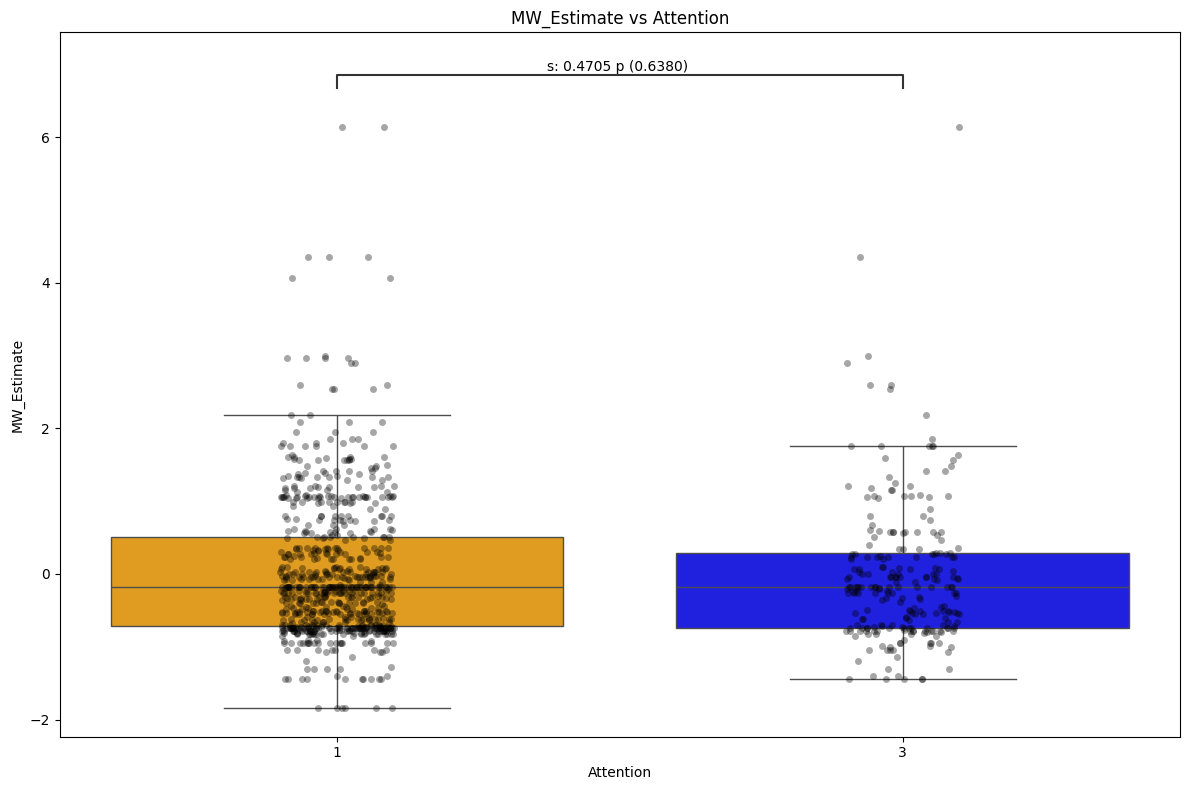

In [33]:
### Create a Color Palette:
custom_cmap = LinearSegmentedColormap.from_list(
    "orange_blue", ["orange", "blue"]
)
colors = custom_cmap(np.linspace(0,256,4,dtype=int))

pdf_path = os.path.join(savePathFeatures, "Checks.pdf")
pdfs_Check = PdfPages(pdf_path)


fig1 = annotBoxPlots(merged,'MW_Estimate','Attention',custom_cmap)
pdfs_Check.savefig(fig1)
plt.show(fig1)

In [34]:
ranksums(merged[merged['Tracking'] == 'UNTRACKED']['Attention'],merged[merged['Tracking'] == 'TRACKED']['Attention'])

RanksumsResult(statistic=0.1676142040495207, pvalue=0.8668867960823106)

TRACKED_Att1 vs. TRACKED_Att3: s: 4.4634 p (0.0000) ***
UNTRACKED_Att1 vs. UNTRACKED_Att3: s: 4.6883 p (0.0000) ***
UNTRACKED_Att3 vs. TRACKED_Att1: s: -4.1866 p (0.0000) ***
UNTRACKED_Att1 vs. TRACKED_Att1: s: 0.8044 p (0.4211) 
UNTRACKED_Att3 vs. TRACKED_Att3: s: 0.2249 p (0.8221) 
UNTRACKED_Att1 vs. TRACKED_Att3: s: 4.9391 p (0.0000) ***


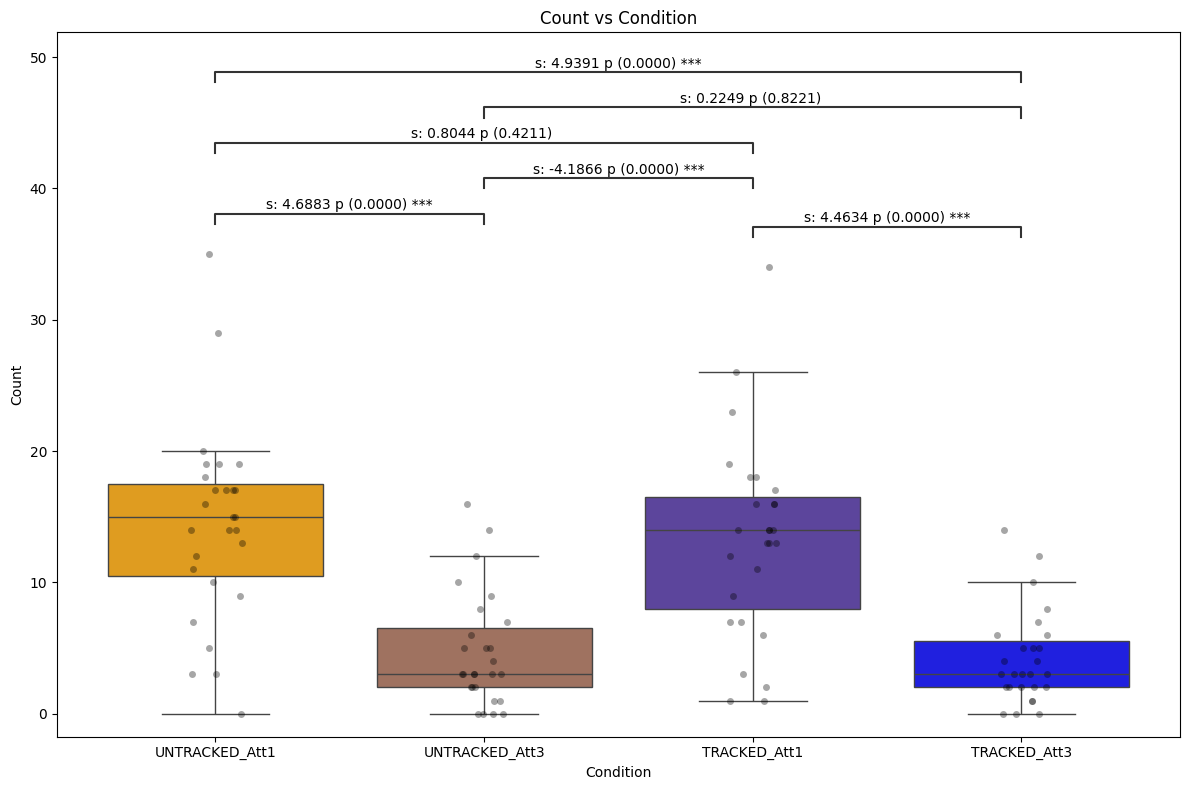

In [35]:
subj_counts = pd.DataFrame({
    'UNTRACKED_Att1': merged[(merged['Tracking'] == 'UNTRACKED') & (merged['Attention'] == 1)].groupby('Subject')['Attention'].count(),
    'UNTRACKED_Att3': merged[(merged['Tracking'] == 'UNTRACKED') & (merged['Attention'] == 3)].groupby('Subject')['Attention'].count(),
    'TRACKED_Att1':   merged[(merged['Tracking'] == 'TRACKED')   & (merged['Attention'] == 1)].groupby('Subject')['Attention'].count(),
    'TRACKED_Att3':   merged[(merged['Tracking'] == 'TRACKED')   & (merged['Attention'] == 3)].groupby('Subject')['Attention'].count()
}).fillna(0).astype(int)

# Reshape for plotting
subj_counts_long = subj_counts.reset_index().melt(id_vars='Subject', var_name='Condition', value_name='Count')

# Example usage:
fig = annotBoxPlots(subj_counts_long, 'Count', 'Condition', custom_cmap)
plt.show(fig)

              Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    Attention 
No. Observations:     985        Method:                REML      
No. Groups:           10         Scale:                 0.7194    
Min. group size:      22         Log-Likelihood:        -1249.1922
Max. group size:      155        Converged:             Yes       
Mean group size:      98.5                                        
------------------------------------------------------------------
                         Coef. Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept                1.397    0.078 18.006 0.000  1.245  1.549
C(Tracking)[T.UNTRACKED] 0.010    0.055  0.184 0.854 -0.097  0.117
trialNum                 0.004    0.002  1.664 0.096 -0.001  0.009
DS Var                   0.019    0.016                           

UNTRACKED vs. TRACKED: s: 0.1676 p (0.8669) 


c:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\analysisFunctions.py:1874: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ax.scatter(grTr.mean().loc[firstContrast].index,grTr.mean().loc[firstContrast],label="Subj Mean Tracked",color = 'blue')


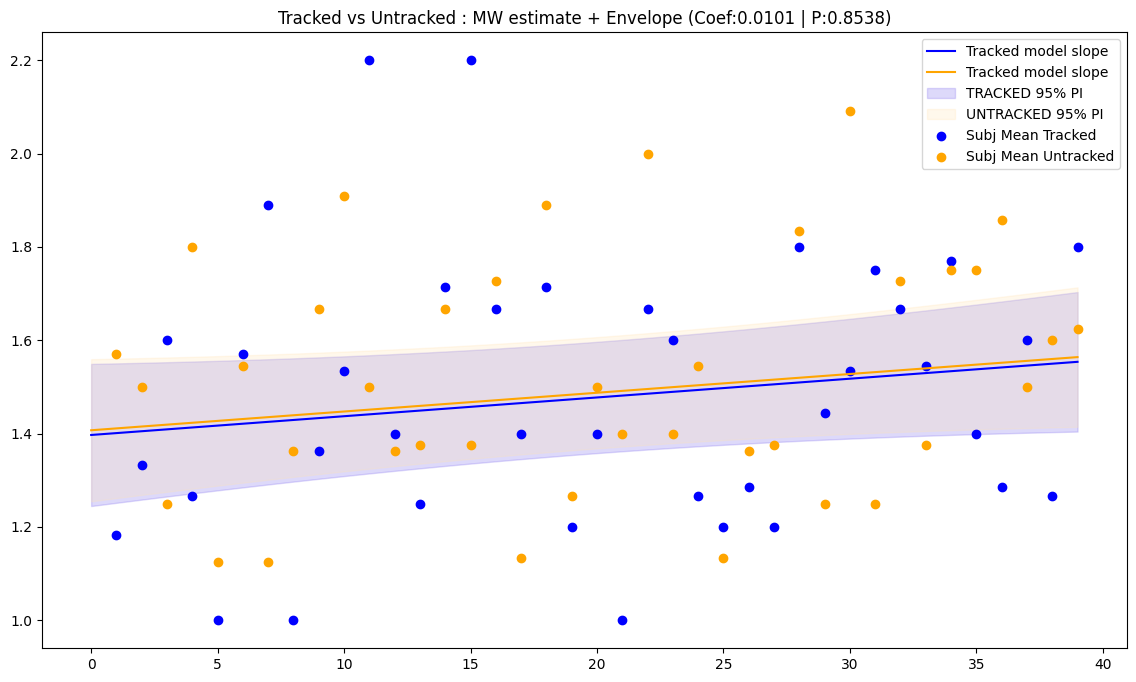

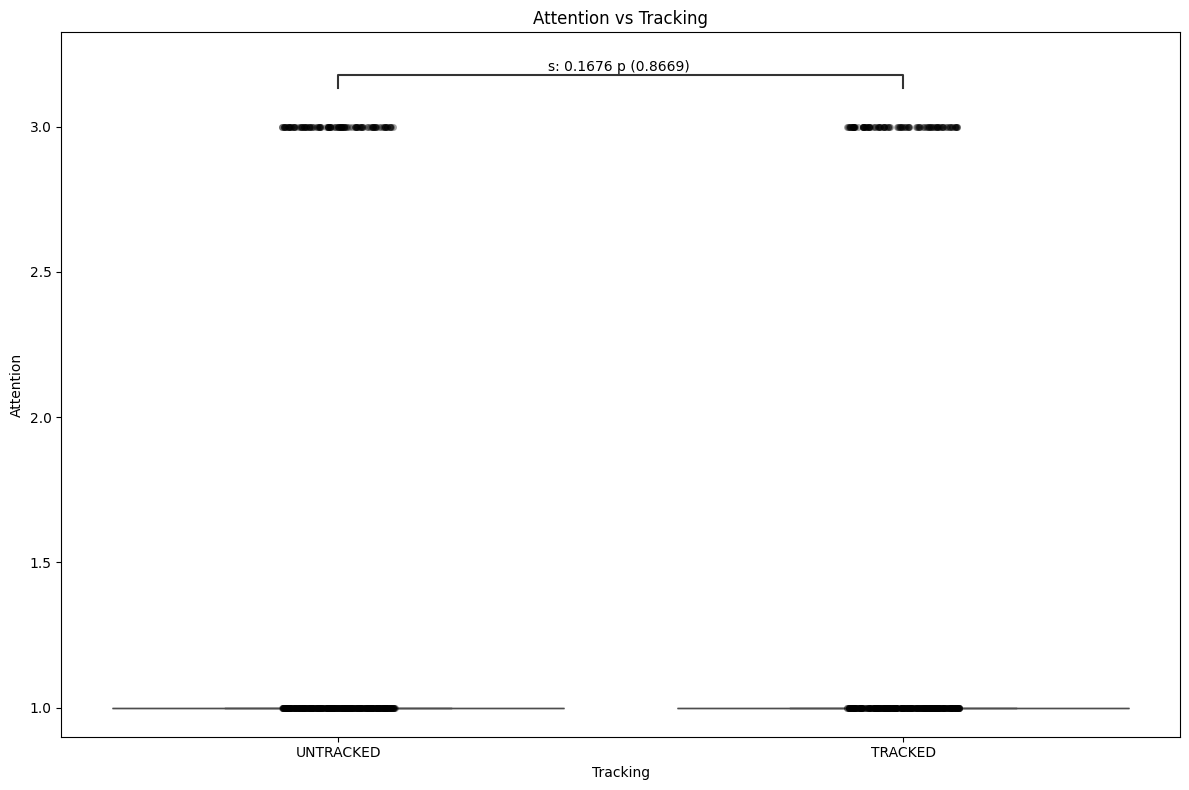

In [36]:

### Get the parameters of a linear model: 
import matplotlib.pyplot as plt

from analysisFunctions import plotTrialTrack

### Model Checks: 
import statsmodels.api  as sm

import statsmodels.formula.api as smf

m = smf.mixedlm("Attention ~ C(Tracking)+trialNum ", data=merged[['DS','trialNum','Tracking','MW_Estimate','Attention']],
                groups="DS",          # random intercept
                #re_formula="~Tracking",         # adds random slope

               ).fit()
print(m.summary())   

fig, ax = plt.subplots(figsize=(14, 8))
plotTrialTrack(m,'Attention',merged,ax,titl=f"Tracked vs Untracked : MW estimate + Envelope (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})" )


pdfs_Check.savefig(fig)

fig1 = annotBoxPlots(merged,'Attention','Tracking',custom_cmap)
pdfs_Check.savefig(fig1)

pdfs_Check.close()


In [37]:
merged

MW_Estimate GazeDifference Pupil_Diameter               \
                                                  Mean                
                                              Left_Eye    Right_Eye   
0        0.0    1.151388      82.308603    4381.319465  4279.315800   
1        0.0    1.151388      82.308603    4381.319465  4279.315800   
2        0.0    1.151388      82.308603    4381.319465  4279.315800   
3        0.0    1.151388      82.308603    4381.319465  4279.315800   
4        1.0   -0.769815      36.474116    4915.607693  4434.471185   
...      ...         ...            ...            ...          ...   
1090  1036.0   -0.063222      26.198336    3983.569299  3907.623675   
1092  1037.0    4.062853      30.417250    4140.107510  4037.408077   
1093  1037.0    4.062853      30.417250    4140.107510  4037.408077   
1094  1038.0    2.998059      21.600760    4227.974282  4100.413388   
1095  1038.0    2.998059      21.600760    4227.974282  4100.413388   

                                                                   ...  \
               Std                    diff                    auc  ...   
          Left_Eye     Right_Eye  Left_Eye Right_Eye     Left_Eye  ...   
0     63266.073017  33602.645894  0.555289  0.487667  4376.924499  ...   
1     63266.073017  33602.645894  0.555289  0.487667  4376.924499  ...   
2     63266.073017  33602.645894  0.555289  0.487667  4376.924499  ...   
3     63266.073017  33602.645894  0.555289  0.487667  4376.924499  ...   
4     21324.827150  11888.845256 -0.226533 -0.248433  4910.833534  ...   
...            ...           ...       ...       ...          ...  ...   
1090  51355.285920  31036.978579 -0.480867 -0.365567  3979.645457  ...   
1092  35047.211177  23644.689273 -0.459700 -0.377700  4135.925842  ...   
1093  35047.211177  23644.689273 -0.459700 -0.377700  4135.925842  ...   
1094  37835.321921  27416.081740 -0.480556 -0.562500  4223.291313  ...   
1095  37835.321921  27416.081740 -0.480556 -0.562500  4223.291313  ...   

     BERTopic MW Prob BERTopic MB Prob Frag-Utt Cosine Sim (Sentance)  \
                                                                        
                                                                        
0            0.041048         0.003280                       0.705140   
1            0.163423         0.401302                       0.238161   
2            0.403603         0.061356                       0.201933   
3            0.037921         0.022928                       0.197639   
4            0.084894         0.005909                       0.466486   
...               ...              ...                            ...   
1090         0.047670         0.007239                       0.184195   
1092         0.235722         0.003953                       0.298739   
1093         0.123436         0.023944                       0.361540   
1094         0.681067         0.192636                       0.250241   
1095         0.410138         0.007382                       0.169078   

     Frag-Utt Cosine Sim (Lemma) Frag-Utt Word Mover Distance Bert Perplexity  \
                                                                                
                                                                                
0                       0.978090                     0.993028      183.375958   
1                       0.606440                     1.082113      114.957813   
2                       0.595167                     1.081804       21.707363   
3                       0.593843                     1.145427       83.134065   
4                       0.966863                     1.042697      307.434135   
...                          ...                          ...             ...   
1090                    0.632719                     1.097047       39.877442   
1092                    0.577279                     1.036595       23.880851   
1093                    0.611934                     1.011705      

           Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  MW_Estimate
No. Observations:  985      Method:              REML       
No. Groups:        10       Scale:               0.9630     
Min. group size:   22       Log-Likelihood:      inf        
Max. group size:   155      Converged:           Yes        
Mean group size:   98.5                                     
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept          0.000                                    
C(Attention)[T.3] -0.050    0.074 -0.674 0.500 -0.195  0.095
trialNum           0.001    0.003  0.535 0.593 -0.004  0.007
DS Var             0.000                                    



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\starteg

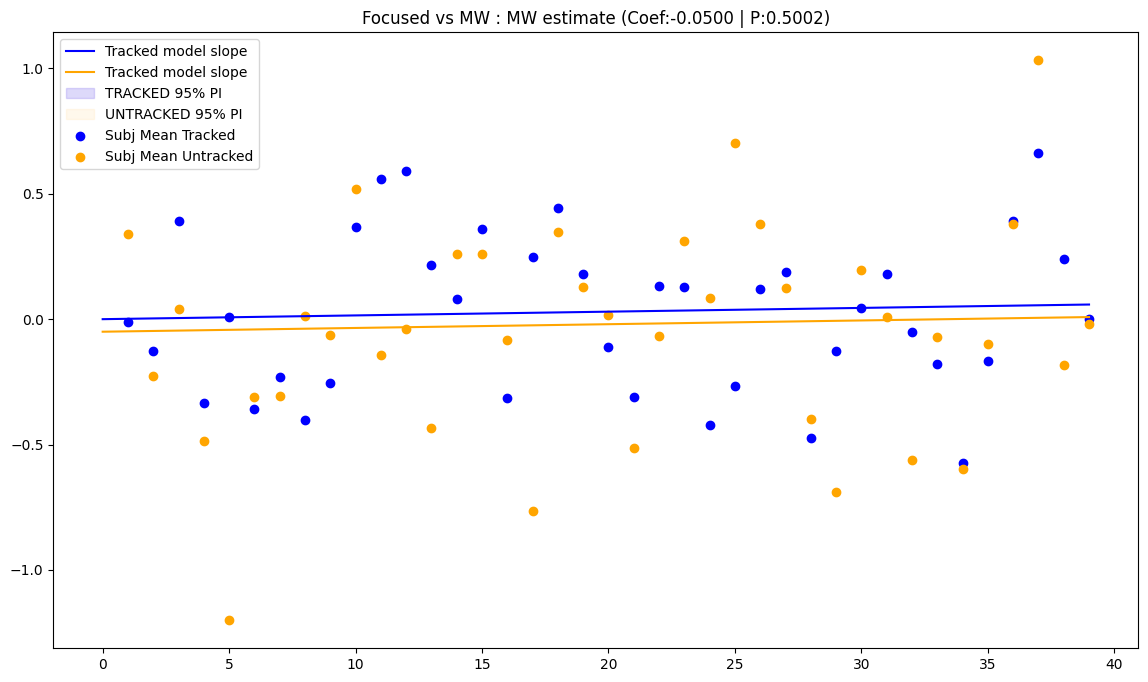

In [38]:
# Fit the mixed effects model
m = smf.mixedlm("MW_Estimate ~ C(Attention) + trialNum", data=merged,
                groups="DS",  # Random intercept
                ).fit()


fig, ax = plt.subplots(figsize=(14, 8))
plotTrialTrack(m,'MW_Estimate',merged,ax,titl=f"Focused vs MW : MW estimate (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})",anlysisName = 'Attention',firstContrast=1,lastContrast =3 )
print(m.summary())   
fig.savefig(os.path.join(savePathFeatures,'plot.png'))

## (1) Statistical Analysis of: MW_Estimate Predictions:


Here we Predict and Place in a single DataFrame A Simple Predictions of MW_Estimate by Utterance Features:
Additionally With Controll for Trial Number (and Possibly Tracking~Untracking) 

This Aims at seeing which Lexical Variability Features can Predict MW_Estimate (And thus in high vs Low MW Estimate are different)

In [39]:

def plot_pupil_vs_mw_Att(m, currentDf, ind, ax=None,meas='Pupil',target='MW_Estimate',split='Attention',meas1=1,meas2=2):
    """
    Plot Pupil vs MW_Estimate with linear fits for TRACKED and UNTRACKED groups.
    
    Parameters:
    - m: Fitted mixed effects model.
    - currentDf: DataFrame containing the data.
    - ind: Tuple indicating the current column (e.g., ('Pupil', 'Diameter')).
    - ax: Matplotlib Axes object. If None, a new figure will be created.
    """
    # Create a new figure and axis if no Axes object is provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    # Define linear functions for TRACKED and UNTRACKED
    # Get Model Values and lambdas for 
    if split != None:
        mnames = ['Intercept'] + [i for i in m.params.keys() if split in  i]
        mvals = [0] + [m.params[i] for i in m.params.keys() if split in  i]
        linfuns = [lambda x, v=val: m.params[m.params.keys()[0]] + m.params[target] * x + v for val in mvals]
   
        #Get Values of Split:
        svals = currentDf[split].unique()
        svals.sort()

        ### Create a Color Palette:
        custom_cmap = LinearSegmentedColormap.from_list(
            "orange_blue", ["orange", "blue"]
        )

        colors = custom_cmap(np.linspace(0,256,4,dtype=int))

        # Create a custom colormap from orange to blue


        for i,sv in enumerate(svals):
        # Scatter plot for TRACKED and UNTRACKED
            print(mnames[i])
            ax.scatter(currentDf[currentDf[split] == sv][target],
                    currentDf[currentDf[split] == sv][meas], color=colors[i],
                    label=f"{mnames[i]} (Coef: {m.params[mnames[i]]:1.3f}) Pval: {m.pvalues[mnames[i]]:1.4f}")
       
            Lab = "".join([" " for j in mnames[i]])
            ax.plot(currentDf[target], linfuns[i](currentDf[target]), color=colors[i])
    else: 
        linfun =lambda x: m.params[m.params.keys()[0]] + m.params[m.params.keys()[1]] * x 

        ax.scatter(currentDf[target],
                currentDf[meas],
                color='orange', label=f"Trial: (Coef: {m.params[m.params.keys()[2]]:1.4f} | P: {m.pvalues[m.params.keys()[2]]:1.4f})")

        ax.plot(currentDf[target], linfun(currentDf[target]), 'b--', label="Tracked Fit")
    # Add labels, title, and legend
    ax.set_xlabel('MW Estimate')
    ax.set_ylabel(f"{meas} Measure: {ind[0]} // {ind[1]}")
    ax.set_title(f"{ind[0]} // {ind[1]}: (Coef: {m.params[m.params.keys()[meas2]]:1.4f} P: {m.pvalues[m.params.keys()[meas2]]:1.4f})")
    ax.legend()

    # Add a suptitle if it's a standalone plot
    if ax is None:
        plt.suptitle(f"MW Estimate vs {meas} Measure")
        plt.show()




def write_sheet(all_stats, sheet_name, writer):
    # write without merged cells so row/col positions are predictable
    all_stats.to_excel(writer, sheet_name=sheet_name, merge_cells=False)

    # bold entire row when P <= 0.05 (xlsxwriter uses 0-based rows)
    wb = writer.book
    ws = writer.sheets[sheet_name]
    bold = wb.add_format({"bold": True})
    start_row = 1  # first data row (row 0 is header)
    for r, pval in enumerate(all_stats["P"], start=start_row):
        try:
            if pd.notna(pval) and float(pval) <= 0.05:
                ws.set_row(r, None, bold)
        except Exception:
            pass

### Predicting Mind Wandering by Semantic Featuures while controlling for TRACKED

In [40]:
import statsmodels.formula.api as smf
from analysisFunctions import plot_pupil_vs_mw
models = []

pdf_path = os.path.join(savePathFeatures, "MW_Estimate_Semantic_Tr.pdf")
pdfs_MWES_Tr = PdfPages(pdf_path)
out_path = os.path.join(savePathFeatures, "mixedlm_fixed_effects_long.xlsx")

stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)
ORDER = ['Intercept', 'Tracking[T.UNTRACKED]','Utterance', 'trialNum']




for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Tracked','Attention'],axis=1).columns.get_level_values(0))[2:])):
    print("\n\n=============================================================")
    print(f"======== Test for MW Estimate vs {ind} =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = merged[['trialNum','DS','MW_Estimate','Tracking',ind]]
    currentDf.columns = [ 'trialNum','DS', 'MW_Estimate', 'Tracking','Utterance']

    
    # Clean the data
    currentDf = currentDf.dropna(subset=['MW_Estimate', 'Tracking', 'trialNum','Utterance'])  # Drop rows with NaN
    currentDf = currentDf[currentDf['Utterance'] - currentDf['Utterance'].mean() <3*currentDf['Utterance'].std()] #Rule out outliers by 3 sigma rule:


    # Fit the mixed effects model
    m = smf.mixedlm("MW_Estimate ~ Utterance + Tracking+ trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R



    # ---- collect fixed-effect stats into a tiny table ----

    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f"MW_Estimate vs {ind}"
    stats_tables[analysis_name] = tbl


    


    fig, ax = plt.subplots(figsize=(14, 8))
    plot_pupil_vs_mw(m, currentDf[['MW_Estimate','DS','Tracking','trialNum','Utterance']], [f"MW_Estimate vs {ind}",""], ax=ax,meas='MW_Estimate',target='Utterance',tracking=True,meas1=3,meas2=2)

    pdfs_MWES_Tr.savefig(fig)
    plt.close(fig)

pdfs_MWES_Tr.close()
all_stats_MWES_Tr = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_MWES_Tr.index.names or []) else -1
all_stats_MWES_Tr = all_stats_MWES_Tr[~all_stats_MWES_Tr.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_MWES_Tr

C:\Users\barak\AppData\Local\Temp\ipykernel_35368\2510287294.py:15: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Tracked','Attention'],axis=1).columns.get_level_values(0))[2:])):




======== Test for MW Estimate vs Utterance Length =======



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\starteg

             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   MW_Estimate
No. Observations:    979       Method:               REML       
No. Groups:          10        Scale:                0.9504     
Min. group size:     22        Log-Likelihood:       inf        
Max. group size:     150       Converged:            Yes        
Mean group size:     97.9                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             -0.000                                    
Tracking[T.UNTRACKED]  0.278    0.064  4.352 0.000  0.153  0.404
Utterance             -0.000    0.000 -0.171 0.864 -0.001  0.001
trialNum               0.002    0.003  0.634 0.526 -0.004  0.007
DS Var                 0.000                                    



======== Test for MW Estimate vs lem

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\starteg

...

             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   MW_Estimate
No. Observations:    966       Method:               REML       
No. Groups:          10        Scale:                0.9580     
Min. group size:     22        Log-Likelihood:       -1367.3963 
Max. group size:     154       Converged:            Yes        
Mean group size:     96.6                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             -0.188    0.085 -2.215 0.027 -0.354 -0.022
Tracking[T.UNTRACKED]  0.292    0.063  4.622 0.000  0.168  0.415
Utterance              0.000    0.000  0.467 0.641 -0.000  0.000
trialNum               0.001    0.003  0.415 0.678 -0.004  0.007
DS Var                 0.000                                    



======== Test for MW Estimate vs GLM

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   MW_Estimate
No. Observations:    966       Method:               REML       
No. Groups:          10        Scale:                0.9606     
Min. group size:     22        Log-Likelihood:       -1367.7349 
Max. group size:     154       Converged:            Yes        
Mean group size:     96.6                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             -0.207    0.093 -2.227 0.026 -0.390 -0.025
Tracking[T.UNTRACKED]  0.290    0.063  4.592 0.000  0.166  0.414
Utterance              0.000    0.000  0.626 0.531 -0.000  0.000
trialNum               0.001    0.003  0.516 0.606 -0.004  0.007
DS Var                 0.000                                    



======== Test for MW Estimate vs Sem

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Coef  \
analysis                                         stat                              
MW_Estimate vs Utterance Length                  Tracking[T.UNTRACKED]  0.278492   
                                                 Utterance             -0.000064   
                                                 trialNum               0.001766   
MW_Estimate vs lemmaN                            Tracking[T.UNTRACKED]  0.271915   
                                                 Utterance             -0.002783   
...                                                                          ...   
MW_Estimate vs GLM Perplexity (Fragment Context) Utterance              0.000027   
                                                 trialNum               0.001456   
MW_Estimate vs Semantic Web Weights of Utterance Tracking[T.UNTRACKED]  0.276905   
                                                 Utterance             -0.000418   
                                                 trialNum               0.001227   

                                                                               z  \
analysis                                         stat                              
MW_Estimate vs Utterance Length                  Tracking[T.UNTRACKED]  4.351739   
                                                 Utterance             -0.171385   
                                                 trialNum               0.634189   
MW_Estimate vs lemmaN                            Tracking[T.UNTRACKED]  4.248087   
                                                 Utterance             -0.527899   
...                                                                          ...   
MW_Estimate vs GLM Perplexity (Fragment Context) Utterance              0.626306   
                                                 trialNum               0.516264   
MW_Estimate vs Semantic Web Weights of Utterance Tracking[T.UNTRACKED]  4.356667   
                                                 Utterance             -0.015255   
                                                 trialNum               0.436410   

                                                                               P  \
analysis                                         stat                              
MW_Estimate vs Utterance Length                  Tracking[T.UNTRACKED]  0.000014   
                                                 Utterance              0.863921   
                                                 trialNum               0.525958   
MW_Estimate vs lemmaN                            Tracking[T.UNTRACKED]  0.000022   
                                                 Utterance              0.597569   
...                                                                          ...   
MW_Estimate vs GLM Perplexity (Fragment Context) Utterance              0.531114   
                                                 trialNum               0.605670   
MW_Estimate vs Semantic Web Weights of Utterance Tracking[T.UNTRACKED]  0.000013   
                                                 Utterance              0.987829   
                                                 trialNum               0.662539   

                                                                             Cf1  \
analysis                                         stat                              
MW_Estimate vs Utterance Length                  Tracking[T.UNTRACKED]  0.153063   
                                                 Utterance             -0.000795   
                                                 trialNum              -0.003692   
MW_Estimate vs lemmaN                            Tracking[T.UNTRACKED]  0.146460   
                                                 Utterance             -0.013117   
...                                                                          ...   
MW_Estimate vs GLM Perplexity (Fragment Context) Utterance             -0.000058   
                                         

### Predicting Mind Wandering by Semantic Features PLAIN

In [41]:
import statsmodels.formula.api as smf
from analysisFunctions import plot_pupil_vs_mw
models = []

pdf_path = os.path.join(savePathFeatures, "MW_Estimate_Semantic.pdf")
pdfs_MWES = PdfPages(pdf_path)
out_path = os.path.join(savePathFeatures, "mixedlm_fixed_effects_long.xlsx")

stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)
ORDER = ['Intercept', 'Tracking[T.UNTRACKED]','Utterance', 'trialNum']




for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Tracked','Attention'],axis=1).columns.get_level_values(0))[2:])):
    print("\n\n=============================================================")
    print(f"======== Test for MW Estimate vs {ind} =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = merged[['trialNum','DS','MW_Estimate','Tracking',ind]]
    currentDf.columns = [ 'trialNum','DS', 'MW_Estimate', 'Tracking','Utterance']

    
    # Clean the data
    currentDf = currentDf.dropna(subset=['MW_Estimate', 'Tracking', 'trialNum','Utterance'])  # Drop rows with NaN
    currentDf = currentDf[currentDf['Utterance'] - currentDf['Utterance'].mean() <3*currentDf['Utterance'].std()] #Rule out outliers by 3 sigma rule:


    # Fit the mixed effects model
    m = smf.mixedlm("MW_Estimate ~ Utterance+ trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R



    # ---- collect fixed-effect stats into a tiny table ----

    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f"MW_Estimate vs {ind}"
    stats_tables[analysis_name] = tbl


    


    fig, ax = plt.subplots(figsize=(14, 8))
    plot_pupil_vs_mw(m, currentDf[['MW_Estimate','DS','Tracking','trialNum','Utterance']], [f"MW_Estimate vs {ind}",""], ax=ax,meas='MW_Estimate',target='Utterance',tracking=False,meas1=2,meas2=1)

    pdfs_MWES.savefig(fig)
    plt.close(fig)

pdfs_MWES.close()
all_stats_MWES = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_MWES.index.names or []) else -1
all_stats_MWES = all_stats_MWES[~all_stats_MWES.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_MWES

C:\Users\barak\AppData\Local\Temp\ipykernel_35368\2854633433.py:15: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Tracked','Attention'],axis=1).columns.get_level_values(0))[2:])):




======== Test for MW Estimate vs Utterance Length =======



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\starteg

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: MW_Estimate
No. Observations: 979     Method:             REML       
No. Groups:       10      Scale:              0.9679     
Min. group size:  22      Log-Likelihood:     inf        
Max. group size:  150     Converged:          Yes        
Mean group size:  97.9                                   
----------------------------------------------------------
           Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept  -0.000                                         
Utterance  -0.000     0.000  -0.439  0.661  -0.001   0.001
trialNum    0.002     0.003   0.576  0.565  -0.004   0.007
DS Var      0.000                                         



======== Test for MW Estimate vs lemmaN =======



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\starteg

...

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: MW_Estimate
No. Observations: 966     Method:             REML       
No. Groups:       10      Scale:              0.9783     
Min. group size:  22      Log-Likelihood:     -1376.1288 
Max. group size:  154     Converged:          Yes        
Mean group size:  96.6                                   
----------------------------------------------------------
           Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept  -0.040     0.079  -0.499  0.618  -0.195   0.116
Utterance   0.000     0.000   0.577  0.564  -0.000   0.000
trialNum    0.001     0.003   0.401  0.688  -0.004   0.007
DS Var      0.000                                         



======== Test for MW Estimate vs GLM Perplexity (Fragment Context) =======



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: MW_Estimate
No. Observations: 966     Method:             REML       
No. Groups:       10      Scale:              0.9806     
Min. group size:  22      Log-Likelihood:     -1376.3293 
Max. group size:  154     Converged:          Yes        
Mean group size:  96.6                                   
----------------------------------------------------------
           Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept  -0.052     0.088  -0.589  0.556  -0.223   0.120
Utterance   0.000     0.000   0.592  0.554  -0.000   0.000
trialNum    0.001     0.003   0.484  0.628  -0.004   0.007
DS Var      0.000                                         



======== Test for MW Estimate vs Semantic Web Weights of Utterance =======

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: MW_Estimate
No. Ob

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\starteg

Coef  \
analysis                                          stat                  
MW_Estimate vs Utterance Length                   Utterance -0.000165   
                                                  trialNum   0.001618   
MW_Estimate vs lemmaN                             Utterance -0.004025   
                                                  trialNum   0.001267   
MW_Estimate vs NounsN                             Utterance  0.011423   
                                                  trialNum   0.001246   
MW_Estimate vs VerbsN                             Utterance -0.017977   
                                                  trialNum   0.001477   
MW_Estimate vs LexDiv                             Utterance  0.227836   
                                                  trialNum   0.001426   
MW_Estimate vs Subject LexDiv                     Utterance -0.298687   
                                                  trialNum   0.000458   
MW_Estimate vs All Data LexDiv                    Utterance -4.480278   
                                                  trialNum   0.001220   
MW_Estimate vs Lemma Embeddings BERT              Utterance -0.005629   
                                                  trialNum   0.001260   
MW_Estimate vs Lemma Embeddings FastText          Utterance  0.090077   
                                                  trialNum   0.000930   
MW_Estimate vs Noun Embeddings BERT               Utterance -0.481775   
                                                  trialNum   0.001293   
MW_Estimate vs Verb Embeddings BERT               Utterance  0.116391   
                                                  trialNum  -0.001518   
MW_Estimate vs Word Mover Distance Subject        Utterance  0.546934   
                                                  trialNum   0.001382   
MW_Estimate vs Word Mover Distance Dataset        Utterance  0.371949   
                                                  trialNum   0.001476   
MW_Estimate vs BERTopic Focus Prob                Utterance -0.042330   
                                                  trialNum   0.001335   
MW_Estimate vs BERTopic TRT Prob                  Utterance  0.183412   
                                                  trialNum   0.001498   
MW_Estimate vs BERTopic MW Prob                   Utterance -0.167568   
                                                  trialNum   0.002007   
MW_Estimate vs BERTopic MB Prob                   Utterance -0.512185   
                                                  trialNum   0.001033   
MW_Estimate vs Frag-Utt Cosine Sim (Sentance)     Utterance -0.001120   
                                                  trialNum   0.001619   
MW_Estimate vs Frag-Utt Cosine Sim (Lemma)        Utterance  0.036200   
                                                  trialNum   0.001424   
MW_Estimate vs Frag-Utt Word Mover Distance       Utterance  0.335968   
                                                  trialNum   0.001252   
MW_Estimate vs Bert Perplexity                    Utterance  0.000003   
                                                  trialNum   0.001257   
MW_Estimate vs Bert Perplexity (Fragment Context) Utterance -0.000073   
                                                  trialNum   0.001424   
MW_Estimate vs GLM Perplexity                     Utterance  0.000010   
                                                  trialNum   0.001140   
MW_Estimate vs GLM Perplexity (Fragment Context)  Utterance  0.000026   
                                                  trialNum   0.001379   
MW_Estimate vs Semantic Web Weights of Utterance  Utterance  0.004519   
                                                  trialNum   0.001137   

                                                                    z  \
analysis                                          stat                  
MW_Estimate vs Utterance Length                   Utterance -0.438754   
                                                 

### (2) Test whether the MW_estimates are dependent on Utterance with controll for Attention

This is a simple Check - to further ascertain the relation between the attentionality in Utterances and MW_estimates - ideally we could totally omit that, but it serves as a controll 

IF Given Feature cannot Distinguish between Attentionality AND MW_Estimates-  then it should be removed


**This Particular Analysis is not very informative - It can be used to see whether there is an indication of mediation**

In [42]:
import statsmodels.formula.api as smf
from analysisFunctions import plot_pupil_vs_mw
models = []

pdf_path = os.path.join(savePathFeatures, "MW_Estimate_Semantic_Att.pdf")
pdfs_MWES_Att = PdfPages(pdf_path)

stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)
ORDER = ['Intercept', 'C(Attention)[T.2]', 'C(Attention)[T.3]', 'C(Attention)[T.4]',
         'Utterance', 'trialNum']



for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Tracked','Attention'],axis=1).columns.get_level_values(0))[2:])):
    print("\n\n=============================================================")
    print(f"======== Test for MW Estimate vs {ind} =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = merged[['trialNum','DS','MW_Estimate','Attention','Tracking',ind]]
    currentDf.columns = [ 'trialNum','DS', 'MW_Estimate','Attention', 'Tracking','Utterance']

    
    # Clean the data
    currentDf = currentDf.dropna(subset=['MW_Estimate','Attention', 'Tracking', 'trialNum','Utterance'])  # Drop rows with NaN
    currentDf = currentDf[currentDf['Utterance'] - currentDf['Utterance'].mean() <3*currentDf['Utterance'].std()] #Rule out outliers by 3 sigma rule:


    # Fit the mixed effects model
    m = smf.mixedlm("MW_Estimate ~ Utterance + C(Attention)+ trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R



    # ---- collect fixed-effect stats into a tiny table ----

    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f"MW_Estimate vs {ind}"
    stats_tables[analysis_name] = tbl


    # ---- Plots 
    fig, ax = plt.subplots(figsize=(14, 8))

    plot_pupil_vs_mw_Att(m, currentDf,  [f"MW_Estimate vs {ind}",""], ax=ax,meas='MW_Estimate',target='Utterance',split='Attention',meas1=5,meas2=4)

    pdfs_MWES_Att.savefig(fig)
    plt.close(fig)

pdfs_MWES_Att.close()

all_stats_MWES_Att = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_MWES_Att.index.names or []) else -1
all_stats_MWES_Att = all_stats_MWES_Att[~all_stats_MWES_Att.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_MWES_Att

C:\Users\barak\AppData\Local\Temp\ipykernel_35368\417760427.py:14: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Tracked','Attention'],axis=1).columns.get_level_values(0))[2:])):




======== Test for MW Estimate vs Utterance Length =======



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\starteg

           Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  MW_Estimate
No. Observations:  979      Method:              REML       
No. Groups:        10       Scale:               0.9686     
Min. group size:   22       Log-Likelihood:      inf        
Max. group size:   150      Converged:           Yes        
Mean group size:   97.9                                     
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept          0.000                                    
C(Attention)[T.3] -0.040    0.076 -0.527 0.598 -0.188  0.108
Utterance         -0.000    0.000 -0.379 0.705 -0.001  0.001
trialNum           0.002    0.003  0.601 0.548 -0.004  0.007
DS Var             0.000                                    

Intercept
C(Attention)[T.3]


======== Test for MW Estimate vs lemmaN =======



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\starteg

...

           Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  MW_Estimate
No. Observations:  966      Method:              REML       
No. Groups:        10       Scale:               0.9791     
Min. group size:   22       Log-Likelihood:      -1377.7065 
Max. group size:   154      Converged:           Yes        
Mean group size:   96.6                                     
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         -0.031    0.081 -0.383 0.701 -0.191  0.128
C(Attention)[T.3] -0.034    0.074 -0.453 0.651 -0.179  0.112
Utterance          0.000    0.000  0.542 0.588 -0.000  0.000
trialNum           0.001    0.003  0.423 0.672 -0.004  0.007
DS Var             0.000                                    

Intercept
C(Attention)[T.3]


======== Test for MW Estimate vs GLM Perplexity (Fragment Context)

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


           Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  MW_Estimate
No. Observations:  966      Method:              REML       
No. Groups:        10       Scale:               0.9814     
Min. group size:   22       Log-Likelihood:      -1377.9049 
Max. group size:   154      Converged:           Yes        
Mean group size:   96.6                                     
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         -0.044    0.089 -0.489 0.625 -0.218  0.131
C(Attention)[T.3] -0.034    0.074 -0.451 0.652 -0.179  0.112
Utterance          0.000    0.000  0.569 0.570 -0.000  0.000
trialNum           0.001    0.003  0.508 0.611 -0.004  0.007
DS Var             0.000                                    

Intercept
C(Attention)[T.3]


======== Test for MW Estimate vs Semantic Web Weights of Utterance

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\starteg

Coef  \
analysis                                         stat                          
MW_Estimate vs Utterance Length                  C(Attention)[T.3] -0.039819   
                                                 Utterance         -0.000143   
                                                 trialNum           0.001690   
MW_Estimate vs lemmaN                            C(Attention)[T.3] -0.034861   
                                                 Utterance         -0.003778   
...                                                                      ...   
MW_Estimate vs GLM Perplexity (Fragment Context) Utterance          0.000025   
                                                 trialNum           0.001451   
MW_Estimate vs Semantic Web Weights of Utterance C(Attention)[T.3] -0.052905   
                                                 Utterance          0.005656   
                                                 trialNum           0.001243   

                                                                           z  \
analysis                                         stat                          
MW_Estimate vs Utterance Length                  C(Attention)[T.3] -0.526993   
                                                 Utterance         -0.379002   
                                                 trialNum           0.600637   
MW_Estimate vs lemmaN                            C(Attention)[T.3] -0.460587   
                                                 Utterance         -0.707545   
...                                                                      ...   
MW_Estimate vs GLM Perplexity (Fragment Context) Utterance          0.568744   
                                                 trialNum           0.508387   
MW_Estimate vs Semantic Web Weights of Utterance C(Attention)[T.3] -0.709157   
                                                 Utterance          0.206388   
                                                 trialNum           0.442752   

                                                                           P  \
analysis                                         stat                          
MW_Estimate vs Utterance Length                  C(Attention)[T.3]  0.598198   
                                                 Utterance          0.704686   
                                                 trialNum           0.548082   
MW_Estimate vs lemmaN                            C(Attention)[T.3]  0.645095   
                                                 Utterance          0.479228   
...                                                                      ...   
MW_Estimate vs GLM Perplexity (Fragment Context) Utterance          0.569530   
                                                 trialNum           0.611182   
MW_Estimate vs Semantic Web Weights of Utterance C(Attention)[T.3]  0.478227   
                                                 Utterance          0.836488   
                                                 trialNum           0.657945   

                                                                         Cf1  \
analysis                                         stat                          
MW_Estimate vs Utterance Length                  C(Attention)[T.3] -0.187910   
                                                 Utterance         -0.000884   
                                                 trialNum          -0.003826   
MW_Estimate vs lemmaN                            C(Attention)[T.3] -0.183206   
                                                 Utterance         -0.014243   
...                                                                      ...   
MW_Estimate vs GLM Perplexity (Fragment Context) Utterance         -0.000061   
                                                 trialNum          -0.004144   
MW_Estimate vs Semantic Web Weights of Utterance C(Attention)[T.3] -0.199123   
                                                 Utterance         -0

### (3) Statistical Analysis of: Utterance Prediction by Tracking

Here We try to see whether our Utterance Features can predict TRACKING --> Thus Answering at least some questions Whether they Differ depending on IMPORTANCE of a given fragment for a current subject

In [43]:
currentDf

,trialNum,DS,MW_Estimate,Attention,Tracking,Utterance
0,1.0,DS01,1.151388,1,UNTRACKED,5.054545
1,1.0,DS01,1.151388,3,UNTRACKED,5.185714
2,1.0,DS01,1.151388,3,UNTRACKED,5.027778
3,1.0,DS01,1.151388,1,UNTRACKED,4.840000
4,2.0,DS01,-0.769815,1,TRACKED,4.840000
...,...,...,...,...,...,...
1090,37.0,DS26,-0.063222,1,TRACKED,6.688889
1092,38.0,DS26,4.062853,1,UNTRACKED,5.114286
1093,38.0,DS26,4.062853,1,UNTRACKED,5.500000
1094,39.0,DS26,2.998059,3,TRACKED,4.353333


In [ ]:
import statsmodels.formula.api as smf
from analysisFunctions import plot_pupil_vs_mw
models = []
pdf_path = os.path.join(savePathFeatures, "Tr_semantic.pdf")
pdfs_SEM_Tr = PdfPages(pdf_path)


stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)
ORDER = ['Intercept', 'Tracking[T.UNTRACKED]', 'trialNum']




for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Tracked'],axis=1).columns.get_level_values(0))[2:])):
    print("\n\n=============================================================")
    print(f"======== Test for {ind} vs Tracking =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = merged[['trialNum','DS','MW_Estimate','Tracking',ind]]
    currentDf.columns = [ 'trialNum','DS', 'MW_Estimate', 'Tracking','Utterance']
    currentDf['trialNum'] = pd.to_numeric(currentDf['trialNum'], errors='coerce')  # Ensure numeric

    currentDf['Utterance'] = pd.to_numeric(currentDf['Utterance'], errors='coerce')  # Ensure numeric

    # Clean the data
    currentDf = currentDf.dropna(subset=['MW_Estimate', 'Tracking', 'trialNum','Utterance'])  # Drop rows with NaN
    currentDf['Tracking_bin'] = (currentDf['Tracking'].astype(str).str.upper() == 'TRACKED').astype(int)

    # Fit the mixed effects model

    m = smf.mixedlm("Tracking_bin ~ Utterance + trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R

    
    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f"MW_Estimate vs {ind}"
    stats_tables[analysis_name] = tbl



    fig, ax = plt.subplots(figsize=(14, 8))
    plotTrialTrack(m,"Utterance",currentDf,ax,titl=f" {ind} (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})")

    pdfs_SEM_Tr.savefig(fig)
    plt.close(fig)

pdfs_SEM_Tr.close()
all_stats_Tr_SEM = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_Tr_SEM.index.names or []) else -1
all_stats_Tr_SEM = all_stats_Tr_SEM[~all_stats_Tr_SEM.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_Tr_SEM

C:\Users\barak\AppData\Local\Temp\ipykernel_35368\1572450211.py:14: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Tracked'],axis=1).columns.get_level_values(0))[2:])):




======== Test for Attention vs Tracking =======

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Tracking_bin
No. Observations: 985     Method:             REML        
No. Groups:       10      Scale:              0.2414      
Min. group size:  22      Log-Likelihood:     -718.7393   
Max. group size:  155     Converged:          Yes         
Mean group size:  98.5                                    
-----------------------------------------------------------
            Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept    0.465     0.068   6.885  0.000   0.333   0.598
Utterance   -0.002     0.019  -0.087  0.931  -0.038   0.035
trialNum     0.000     0.001   0.245  0.806  -0.002   0.003
DS Var       0.028     0.036                               



======== Test for Utterance Length vs Tracking =======

          Mixed Linear Model Regression Results
Model:            Mi

C:\Users\barak\AppData\Local\Temp\ipykernel_25200\1579038394.py:14: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Tracked'],axis=1).columns.get_level_values(0))[2:])):




======== Test for Attention vs Tracking =======

             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   Utterance 
No. Observations:    985       Method:               REML      
No. Groups:          10        Scale:                0.7194    
Min. group size:     22        Log-Likelihood:       -1249.1922
Max. group size:     155       Converged:            Yes       
Mean group size:     98.5                                      
---------------------------------------------------------------
                      Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             1.397    0.078 18.006 0.000  1.245  1.549
Tracking[T.UNTRACKED] 0.010    0.055  0.184 0.854 -0.097  0.117
trialNum              0.004    0.002  1.664 0.096 -0.001  0.009
DS Var                0.019    0.016                           



PermissionError: [Errno 13] Permission denied: 'c:\\Users\\barak\\Documents\\GitHub\\startegicMW_lite\\Experiment\\analysis\\SecondExp\\RecallAnalysis\\FULLextrF_2_NoShort_sFiltered\\Semantic_Tr.pdf'

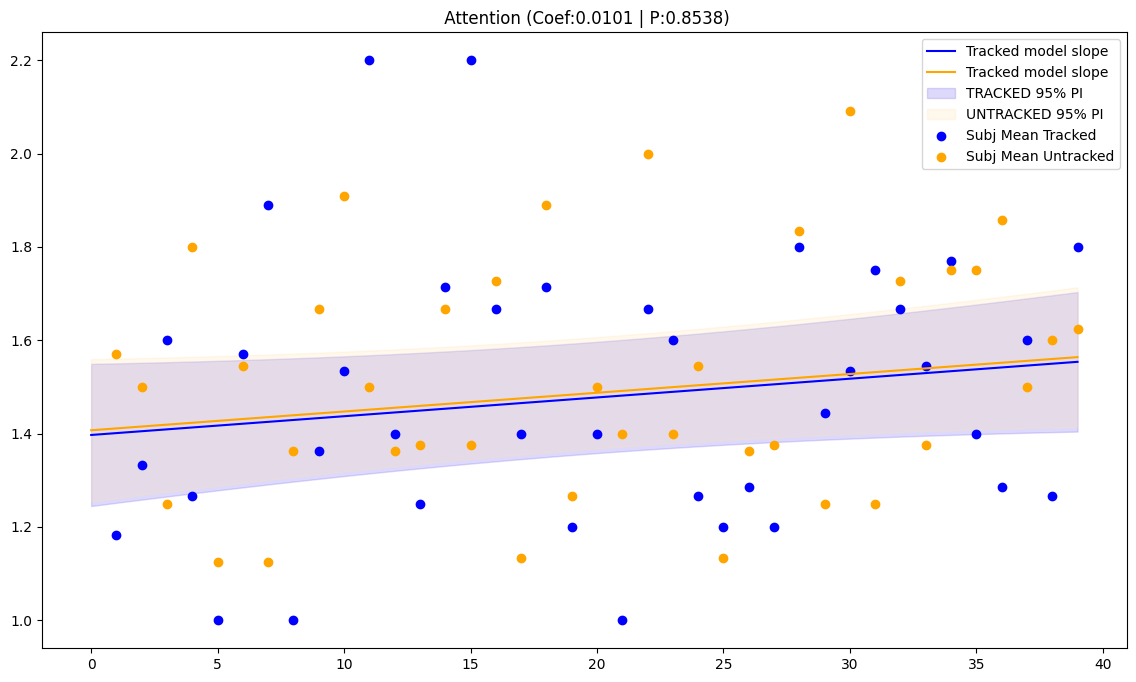

In [ ]:
import statsmodels.formula.api as smf
from analysisFunctions import plot_pupil_vs_mw
models = []
pdf_path = os.path.join(savePathFeatures, "Semantic_Tr.pdf")
pdfs_SEM_Tr = PdfPages(pdf_path)


stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)
ORDER = ['Intercept', 'Tracking[T.UNTRACKED]', 'trialNum']




for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Tracked'],axis=1).columns.get_level_values(0))[2:])):
    print("\n\n=============================================================")
    print(f"======== Test for {ind} vs Tracking =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = merged[['trialNum','DS','MW_Estimate','Tracking',ind]]
    currentDf.columns = [ 'trialNum','DS', 'MW_Estimate', 'Tracking','Utterance']

    
    # Clean the data
    currentDf = currentDf.dropna(subset=['MW_Estimate', 'Tracking', 'trialNum','Utterance'])  # Drop rows with NaN

    # Fit the mixed effects model
    m = smf.mixedlm("Utterance ~ Tracking + trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R

    
    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f"MW_Estimate vs {ind}"
    stats_tables[analysis_name] = tbl



    fig, ax = plt.subplots(figsize=(14, 8))
    plotTrialTrack(m,"Utterance",currentDf,ax,titl=f" {ind} (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})")

    pdfs_SEM_Tr.savefig(fig)
    plt.close(fig)

pdfs_SEM_Tr.close()
all_stats_SEM_Tr = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_SEM_Tr.index.names or []) else -1
all_stats_SEM_Tr = all_stats_SEM_Tr[~all_stats_SEM_Tr.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_SEM_Tr

### (4) Statistical Analysis of: Attention Predictioms:

Here we try to see whether our Lexical Features Differ between Attentionality Conditions. THis and MW is particulary Important as it allows us to see whether MW or Attention truly differ based on our Features 

In [ ]:
import statsmodels.formula.api as smf
from analysisFunctions import plot_pupil_vs_mw
models = []
pdf_path = os.path.join(savePathFeatures, "Att_semantic.pdf")
pdfs_SEM_Att = PdfPages(pdf_path)

stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)
ORDER = ['Intercept', 'C(Attention)[T.2]', 'C(Attention)[T.3]', 'C(Attention)[T.4]', 'trialNum']


for i, ind in enumerate((list(dfAnalysis.drop(['DS','Attention','Tracked','trialNum'],axis=1).columns.get_level_values(0))[2:])):
    print("\n\n=============================================================")
    print(f"======== Test for {ind} vs Tracking =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = merged[['trialNum','DS','Attention','Tracking',ind]]
    currentDf.columns = [ 'trialNum','DS', 'Attention', 'Tracking','Utterance']

    
    # Clean the data
    currentDf = currentDf.dropna(subset=['Attention', 'Tracking', 'trialNum','Utterance'])  # Drop rows with NaN

    # Fit the mixed effects model
    m = smf.mixedlm("Attention ~ Utterance  + trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R

      
    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f"Attention vs {ind}"
    stats_tables[analysis_name] = tbl

    #fig, ax = plt.subplots(figsize=(14, 8))
    #plot_pupil_vs_mw(m, currentDf[['Attention','DS','Tracking','trialNum','Utterance']], [f"Attention vs {ind}",f"(Coef: {m.params[m.params.keys()[1]]:1.4f} // P: {m.pvalues[m.params.keys()[1]]:1.4f}) (Coef: {m.params[m.params.keys()[2]]:1.4f} // P: {m.pvalues[m.params.keys()[2]]:1.4f})"], ax=ax,meas='Utterance',target='Attention',tracking=False,meas1=4,meas2=3)
    fig = annotBoxPlots(currentDf,'Utterance','Attention',custom_cmap,AnName =ind)

    pdfs_SEM_Att.savefig(fig)
    plt.close(fig)

pdfs_SEM_Att.close()
all_stats_att_SEM= pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_att_SEM.index.names or []) else -1
all_stats_att_SEM = all_stats_att_SEM[~all_stats_att_SEM.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_att_SEM



======== Test for Utterance Length vs Tracking =======



C:\Users\barak\AppData\Local\Temp\ipykernel_39692\1516649351.py:11: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  for i, ind in enumerate((list(dfAnalysis.drop(['DS','Attention','Tracked','trialNum'],axis=1).columns.get_level_values(0))[2:])):


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Attention 
No. Observations: 1012    Method:             REML      
No. Groups:       27      Scale:              0.6709    
Min. group size:  26      Log-Likelihood:     -1265.7119
Max. group size:  40      Converged:          Yes       
Mean group size:  37.5                                  
---------------------------------------------------------
           Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------
Intercept  1.187     0.101  11.747  0.000   0.989   1.385
Utterance  0.001     0.000   2.896  0.004   0.000   0.002
trialNum   0.004     0.002   1.909  0.056  -0.000   0.009
DS Var     0.055     0.026                               

1 vs. 3: s: 2.7247 p (0.0064) **


======== Test for lemmaN vs Tracking =======

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Attention 
No. Observations: 1

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Attention
No. Observations: 1012    Method:             REML     
No. Groups:       27      Scale:              0.3513   
Min. group size:  26      Log-Likelihood:     -920.1446
Max. group size:  40      Converged:          Yes      
Mean group size:  37.5                                 
-------------------------------------------------------
              Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.747    0.045 16.621 0.000  0.658  0.835
Utterance     3.204    0.100 31.958 0.000  3.007  3.400
trialNum      0.000    0.002  0.048 0.962 -0.003  0.003
DS Var        0.004    0.007                           

1 vs. 3: s: 19.4415 p (0.0000) ***


======== Test for BERTopic MB Prob vs Tracking =======

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Attention 
No. Observations: 1012    M

Coef  \
analysis                                        stat                   
Attention vs Utterance Length                   trialNum    0.004279   
                                                Utterance   0.001051   
Attention vs lemmaN                             trialNum    0.004375   
                                                Utterance   0.014365   
Attention vs NounsN                             trialNum    0.004338   
                                                Utterance  -0.001763   
Attention vs VerbsN                             trialNum    0.004166   
                                                Utterance   0.032337   
Attention vs LexDiv                             trialNum    0.004348   
                                                Utterance  -0.851063   
Attention vs Subject LexDiv                     trialNum    0.004566   
                                                Utterance   3.363857   
Attention vs All Data LexDiv                    trialNum    0.004412   
                                                Utterance  13.150836   
Attention vs Lemma Embeddings BERT              trialNum    0.004005   
                                                Utterance  -1.244181   
Attention vs Lemma Embeddings FastText          trialNum    0.004338   
                                                Utterance   0.102259   
Attention vs Noun Embeddings BERT               trialNum    0.004289   
                                                Utterance   0.201113   
Attention vs Verb Embeddings BERT               trialNum    0.004431   
                                                Utterance  -0.053971   
Attention vs Word Mover Distance Subject        trialNum    0.004279   
                                                Utterance   1.677696   
Attention vs Word Mover Distance Dataset        trialNum    0.004578   
                                                Utterance   1.014171   
Attention vs BERTopic Focus Prob                trialNum    0.001128   
                                                Utterance  -1.627427   
Attention vs BERTopic TRT Prob                  trialNum    0.004577   
                                                Utterance  -1.152770   
Attention vs BERTopic MW Prob                   trialNum    0.000078   
                                                Utterance   3.203682   
Attention vs BERTopic MB Prob                   trialNum    0.002919   
                                                Utterance   3.061842   
Attention vs Frag-Utt Cosine Sim (Sentance)     trialNum    0.003533   
                                                Utterance  -1.072660   
Attention vs Frag-Utt Cosine Sim (Lemma)        trialNum    0.004333   
                                                Utterance  -0.078032   
Attention vs Frag-Utt Word Mover Distance       trialNum    0.003872   
                                                Utterance   1.691037   
Attention vs Bert Perplexity                    trialNum    0.004362   
                                                Utterance  -0.000002   
Attention vs Bert Perplexity (Fragment Context) trialNum    0.004244   
                                                Utterance  -0.000040   
Attention vs GLM Perplexity                     trialNum    0.004280   
                                                Utterance  -0.000011   
Attention vs GLM Perplexity (Fragment Context)  trialNum    0.004310   
                                                Utterance  -0.000014   
Attention vs Semantic Web Weights of Utterance  trialNum    0.004299   
                                                Utterance  -0.021994   

                                                                   z  \
analysis                                        stat                   
Attention vs Utterance Length                   trialNum    1.909419   
                                                Utterance   2.896336   
Attention vs lemmaN            

In [ ]:
import statsmodels.formula.api as smf
from analysisFunctions import plot_pupil_vs_mw
models = []
pdf_path = os.path.join(savePathFeatures, "Semantic_Att.pdf")
pdfs_SEM_Att = PdfPages(pdf_path)

stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)
ORDER = ['Intercept', 'C(Attention)[T.2]', 'C(Attention)[T.3]', 'C(Attention)[T.4]', 'trialNum']


for i, ind in enumerate((list(dfAnalysis.drop(['DS','Attention','Tracked','trialNum'],axis=1).columns.get_level_values(0))[2:])):
    print("\n\n=============================================================")
    print(f"======== Test for {ind} vs Tracking =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = merged[['trialNum','DS','Attention','Tracking',ind]]
    currentDf.columns = [ 'trialNum','DS', 'Attention', 'Tracking','Utterance']

    
    # Clean the data
    currentDf = currentDf.dropna(subset=['Attention', 'Tracking', 'trialNum','Utterance'])  # Drop rows with NaN

    # Fit the mixed effects model
    m = smf.mixedlm("Attention ~ Utterance  + trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R

      
    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f"Attention vs {ind}"
    stats_tables[analysis_name] = tbl

    #fig, ax = plt.subplots(figsize=(14, 8))
    #plot_pupil_vs_mw(m, currentDf[['Attention','DS','Tracking','trialNum','Utterance']], [f"Attention vs {ind}",f"(Coef: {m.params[m.params.keys()[1]]:1.4f} // P: {m.pvalues[m.params.keys()[1]]:1.4f}) (Coef: {m.params[m.params.keys()[2]]:1.4f} // P: {m.pvalues[m.params.keys()[2]]:1.4f})"], ax=ax,meas='Utterance',target='Attention',tracking=False,meas1=4,meas2=3)
    fig = annotBoxPlots(currentDf,'Utterance','Attention',custom_cmap,AnName =ind)

    pdfs_SEM_Att.savefig(fig)
    plt.close(fig)

pdfs_SEM_Att.close()
all_stats_SEM_Att = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_SEM_Att.index.names or []) else -1
all_stats_SEM_Att = all_stats_SEM_Att[~all_stats_SEM_Att.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_SEM_Att



======== Test for Utterance Length vs Tracking =======



C:\Users\barak\AppData\Local\Temp\ipykernel_39692\76278091.py:11: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  for i, ind in enumerate((list(dfAnalysis.drop(['DS','Attention','Tracked','trialNum'],axis=1).columns.get_level_values(0))[2:])):


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Attention 
No. Observations: 1012    Method:             REML      
No. Groups:       27      Scale:              0.6709    
Min. group size:  26      Log-Likelihood:     -1265.7119
Max. group size:  40      Converged:          Yes       
Mean group size:  37.5                                  
---------------------------------------------------------
           Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------
Intercept  1.187     0.101  11.747  0.000   0.989   1.385
Utterance  0.001     0.000   2.896  0.004   0.000   0.002
trialNum   0.004     0.002   1.909  0.056  -0.000   0.009
DS Var     0.055     0.026                               

1 vs. 3: s: 2.7247 p (0.0064) **


======== Test for lemmaN vs Tracking =======

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Attention 
No. Observations: 1

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Attention
No. Observations: 1012    Method:             REML     
No. Groups:       27      Scale:              0.3513   
Min. group size:  26      Log-Likelihood:     -920.1446
Max. group size:  40      Converged:          Yes      
Mean group size:  37.5                                 
-------------------------------------------------------
              Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.747    0.045 16.621 0.000  0.658  0.835
Utterance     3.204    0.100 31.958 0.000  3.007  3.400
trialNum      0.000    0.002  0.048 0.962 -0.003  0.003
DS Var        0.004    0.007                           

1 vs. 3: s: 19.4415 p (0.0000) ***


======== Test for BERTopic MB Prob vs Tracking =======

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Attention 
No. Observations: 1012    M

Coef  \
analysis                                        stat                   
Attention vs Utterance Length                   trialNum    0.004279   
                                                Utterance   0.001051   
Attention vs lemmaN                             trialNum    0.004375   
                                                Utterance   0.014365   
Attention vs NounsN                             trialNum    0.004338   
                                                Utterance  -0.001763   
Attention vs VerbsN                             trialNum    0.004166   
                                                Utterance   0.032337   
Attention vs LexDiv                             trialNum    0.004348   
                                                Utterance  -0.851063   
Attention vs Subject LexDiv                     trialNum    0.004566   
                                                Utterance   3.363857   
Attention vs All Data LexDiv                    trialNum    0.004412   
                                                Utterance  13.150836   
Attention vs Lemma Embeddings BERT              trialNum    0.004005   
                                                Utterance  -1.244181   
Attention vs Lemma Embeddings FastText          trialNum    0.004338   
                                                Utterance   0.102259   
Attention vs Noun Embeddings BERT               trialNum    0.004289   
                                                Utterance   0.201113   
Attention vs Verb Embeddings BERT               trialNum    0.004431   
                                                Utterance  -0.053971   
Attention vs Word Mover Distance Subject        trialNum    0.004279   
                                                Utterance   1.677696   
Attention vs Word Mover Distance Dataset        trialNum    0.004578   
                                                Utterance   1.014171   
Attention vs BERTopic Focus Prob                trialNum    0.001128   
                                                Utterance  -1.627427   
Attention vs BERTopic TRT Prob                  trialNum    0.004577   
                                                Utterance  -1.152770   
Attention vs BERTopic MW Prob                   trialNum    0.000078   
                                                Utterance   3.203682   
Attention vs BERTopic MB Prob                   trialNum    0.002919   
                                                Utterance   3.061842   
Attention vs Frag-Utt Cosine Sim (Sentance)     trialNum    0.003533   
                                                Utterance  -1.072660   
Attention vs Frag-Utt Cosine Sim (Lemma)        trialNum    0.004333   
                                                Utterance  -0.078032   
Attention vs Frag-Utt Word Mover Distance       trialNum    0.003872   
                                                Utterance   1.691037   
Attention vs Bert Perplexity                    trialNum    0.004362   
                                                Utterance  -0.000002   
Attention vs Bert Perplexity (Fragment Context) trialNum    0.004244   
                                                Utterance  -0.000040   
Attention vs GLM Perplexity                     trialNum    0.004280   
                                                Utterance  -0.000011   
Attention vs GLM Perplexity (Fragment Context)  trialNum    0.004310   
                                                Utterance  -0.000014   
Attention vs Semantic Web Weights of Utterance  trialNum    0.004299   
                                                Utterance  -0.021994   

                                                                   z  \
analysis                                        stat                   
Attention vs Utterance Length                   trialNum    1.909419   
                                                Utterance   2.896336   
Attention vs lemmaN            

In [ ]:
out_path

'c:\\Users\\barak\\Documents\\GitHub\\startegicMW_lite\\Experiment\\analysis\\SecondExp\\RecallAnalysis\\FULLextrF_2_NoShort_sFiltered\\mixedlm_fixed_effects_long.xlsx'

In [ ]:
with pd.ExcelWriter(out_path, engine="xlsxwriter") as writer:
    write_sheet(all_stats_MWES,"MWES",writer)
    write_sheet(all_stats_MWES_Tr,  "MWES_Tr",  writer)
    write_sheet(all_stats_MWES_Att, "MWES_Att",  writer)
    write_sheet(all_stats_SEM_Att, "SEM_Att", writer)
    write_sheet(all_stats_att_SEM,"Att_SEM",writer)
    write_sheet(all_stats_Tr_SEM,"Tr_SEM",writer)
    write_sheet(all_stats_SEM_Tr,"SEM_Tr",writer)

